In [1]:
# Data handling
import numpy as np
import pandas as pd
import os
from pathlib import Path

# Image processing
import cv2

# Machine Learning
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, f1_score

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Warnings
import warnings
warnings.filterwarnings('ignore')

## Load Data

In [2]:
train_base_path = r'C:\Users\Gauri\Downloads\IDSA Project\updated train dataset'
test_base_path = r'C:\Users\Gauri\Downloads\IDSA Project\updated test dataset'
train_csv_path = os.path.join(train_base_path, 'class_label.csv')
test_csv_path = os.path.join(test_base_path, 'class label.csv')

train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)

new_names = ['image_path', 'abnormality', 'pcos_visible']
train_df.columns = new_names
test_df.columns = new_names

train_df = train_df.dropna(subset=['image_path'])
test_df = test_df.dropna(subset=['image_path'])

mapping = {
    'Appears normal': 0,
    'Appears abnormal': 1,
    'Not-visible': 0,
    'Visible': 1
}

train_df['abnormality'] = train_df['abnormality'].map(mapping)
train_df['pcos_visible'] = train_df['pcos_visible'].map(mapping)

train_img_dir = os.path.join(train_base_path, 'images')
test_img_dir = os.path.join(test_base_path, 'images')
train_df['full_path'] = train_df['image_path'].apply(lambda x: os.path.join(train_img_dir, str(x)))
test_df['full_path'] = test_df['image_path'].apply(lambda x: os.path.join(test_img_dir, str(x)))

print(f"Train: {len(train_df)}, Test: {len(test_df)}")
print(f"Train - Normal: {sum(train_df['abnormality']==0)}, Abnormal: {sum(train_df['abnormality']==1)}")

Train: 3200, Test: 1468
Train - Normal: 903, Abnormal: 2297


## Class Distribution

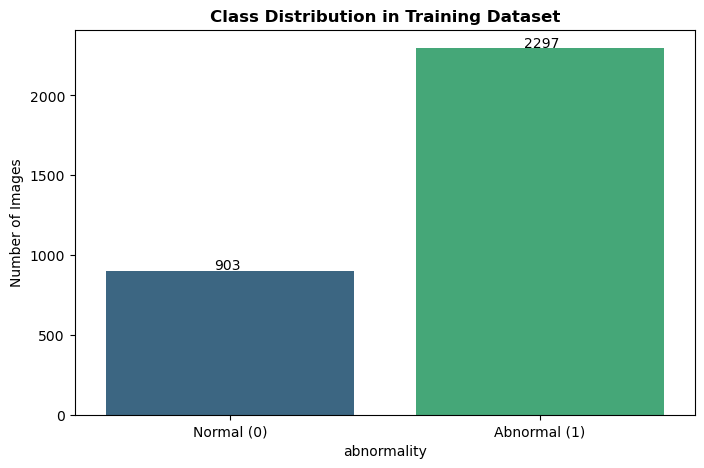

In [3]:
plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x='abnormality', palette='viridis')
plt.title('Class Distribution in Training Dataset', fontweight='bold')
plt.xticks(ticks=[0, 1], labels=['Normal (0)', 'Abnormal (1)'])
plt.ylabel('Number of Images')
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + 0.35, p.get_height() + 5))
plt.show()

## Load Images

In [4]:
IMG_SIZE = 128

def load_train_images(df):
    images, labels = [], []
    for _, row in df.iterrows():
        try:
            if pd.isna(row['abnormality']):
                continue
            img = cv2.imread(row['full_path'], cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype('float32') / 255.0
            images.append(img)
            labels.append(int(row['abnormality']))
        except:
            pass
    return np.array(images), np.array(labels)

def load_test_images(df):
    images = []
    for _, row in df.iterrows():
        try:
            img = cv2.imread(row['full_path'], cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype('float32') / 255.0
            images.append(img)
        except:
            pass
    return np.array(images)

print("Loading images...")
X_train, y_train = load_train_images(train_df)
X_test = load_test_images(test_df)

print(f"Train: {X_train.shape} with labels, Test: {X_test.shape} (no labels)")

Loading images...
Train: (3200, 128, 128) with labels, Test: (1468, 128, 128) (no labels)


## Visualize Training Data

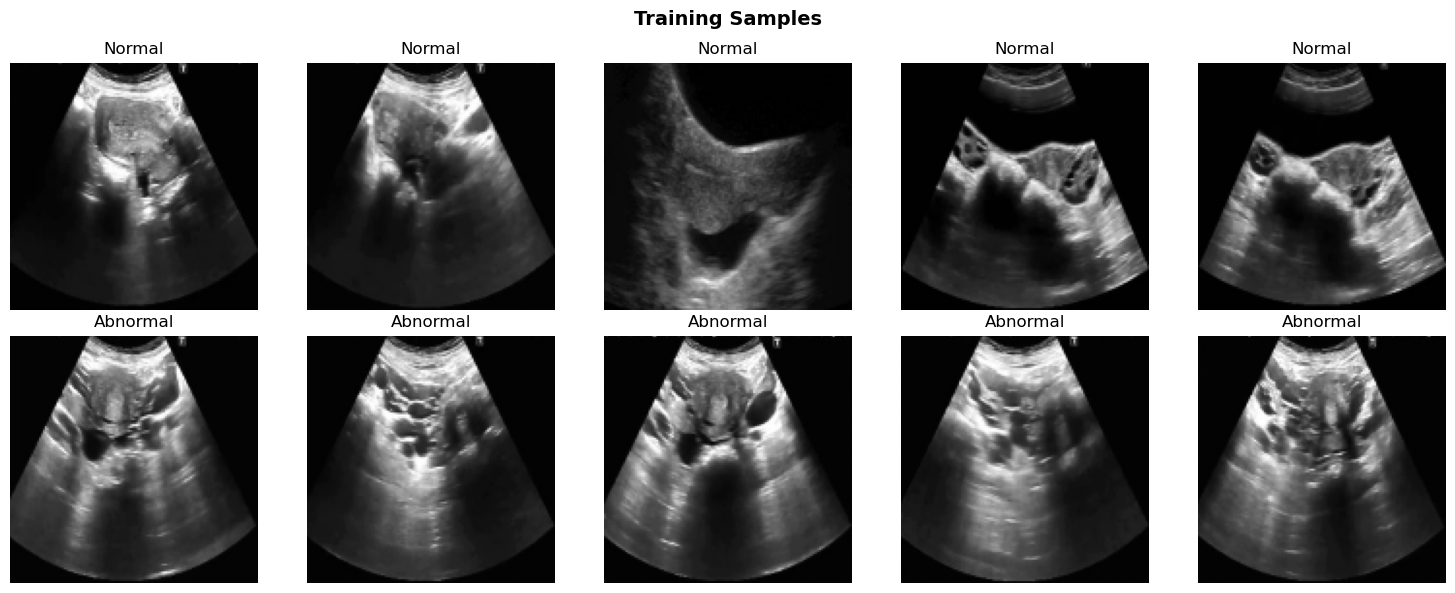

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Training Samples', fontsize=14, fontweight='bold')

normal_idx = np.where(y_train == 0)[0][:5]
abnormal_idx = np.where(y_train == 1)[0][:5]

for i, idx in enumerate(normal_idx):
    axes[0, i].imshow(X_train[idx], cmap='gray')
    axes[0, i].set_title('Normal')
    axes[0, i].axis('off')

for i, idx in enumerate(abnormal_idx):
    axes[1, i].imshow(X_train[idx], cmap='gray')
    axes[1, i].set_title('Abnormal')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

### Average Image per Class

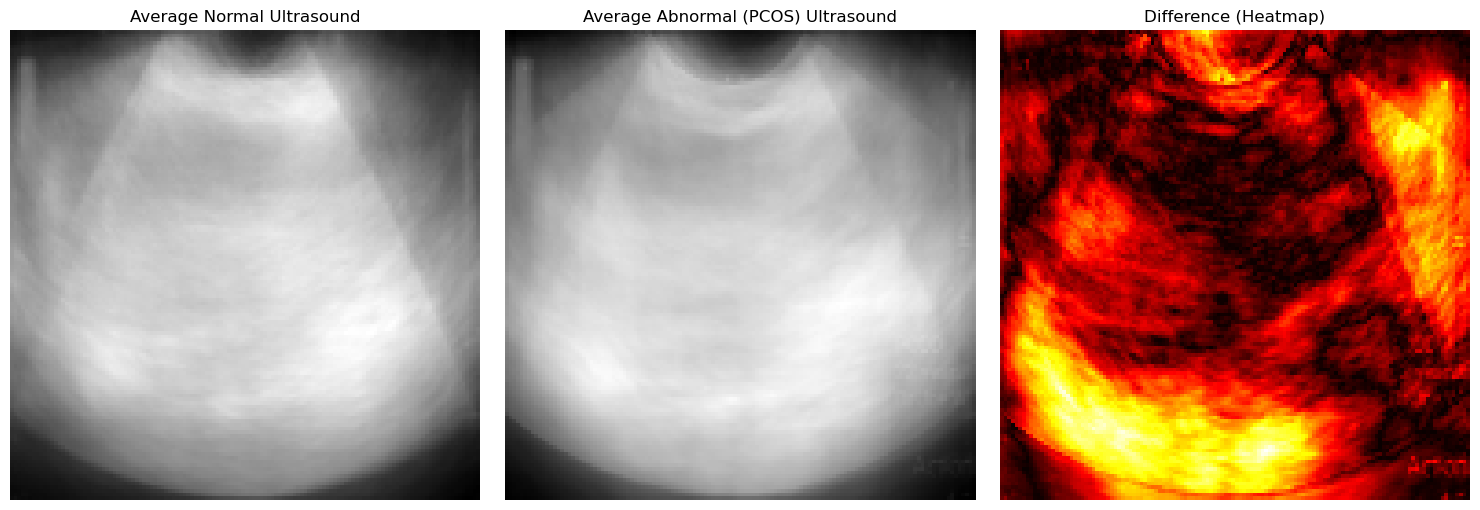

In [6]:
mean_normal = np.mean(X_train[y_train == 0], axis=0)
mean_abnormal = np.mean(X_train[y_train == 1], axis=0)
mean_diff = np.abs(mean_normal - mean_abnormal)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(mean_normal, cmap='gray')
axes[0].set_title('Average Normal Ultrasound')
axes[0].axis('off')

axes[1].imshow(mean_abnormal, cmap='gray')
axes[1].set_title('Average Abnormal (PCOS) Ultrasound')
axes[1].axis('off')

axes[2].imshow(mean_diff, cmap='hot')
axes[2].set_title('Difference (Heatmap)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

### Pixel Intensity Distribution

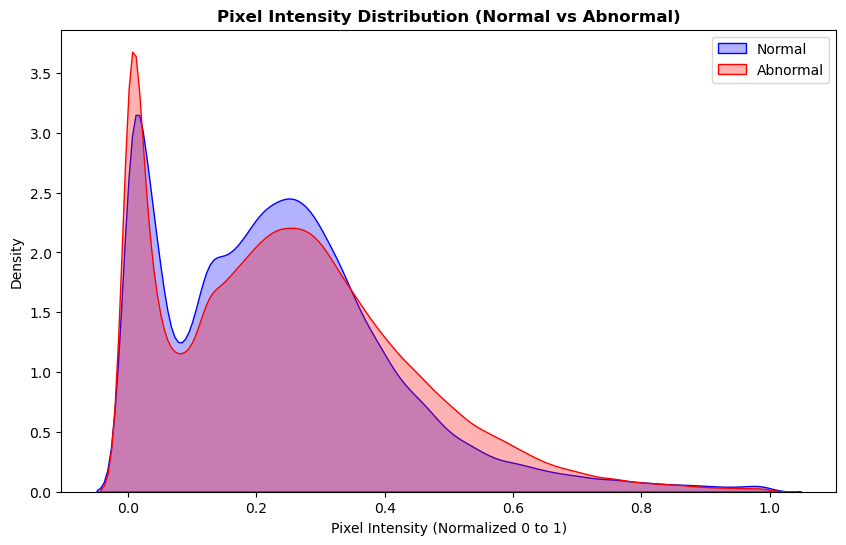

In [7]:
plt.figure(figsize=(10, 6))
# Flatten arrays and plot a subset to compute faster
sns.kdeplot(X_train[y_train == 0].flatten()[::100], label='Normal', color='blue', fill=True, alpha=0.3)
sns.kdeplot(X_train[y_train == 1].flatten()[::100], label='Abnormal', color='red', fill=True, alpha=0.3)
plt.title('Pixel Intensity Distribution (Normal vs Abnormal)', fontweight='bold')
plt.xlabel('Pixel Intensity (Normalized 0 to 1)')
plt.ylabel('Density')
plt.legend()
plt.show()

# PART 1: NAIVE BAYES (Raw Pixels)

## Flatten & Normalize

In [8]:
# Flatten: 128x128 -> 16384 pixels
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

# Normalize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

print(f"Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")

Train: (3200, 16384), Test: (1468, 16384)


## Train Naive Bayes

In [9]:
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

# Predict on test (no labels needed)
y_pred_nb = nb.predict(X_test_scaled)

print(f"  Total predictions: {len(y_pred_nb)}")
print(f"  Normal: {sum(y_pred_nb==0)}, Abnormal: {sum(y_pred_nb==1)}")

  Total predictions: 1468
  Normal: 460, Abnormal: 1008


## Check Performance on Training Data

In [10]:
y_train_pred_nb = nb.predict(X_train_scaled)

accuracy_nb_train = accuracy_score(y_train, y_train_pred_nb)
precision_nb_train = precision_score(y_train, y_train_pred_nb)
recall_nb_train = recall_score(y_train, y_train_pred_nb)
f1_nb_train = f1_score(y_train, y_train_pred_nb)

print("NAIVE BAYES - Training Performance")
print(f"Accuracy:  {accuracy_nb_train:.4f}")
print(f"Precision: {precision_nb_train:.4f}")
print(f"Recall:    {recall_nb_train:.4f}")
print(f"F1-Score:  {f1_nb_train:.4f}")

cm_nb_train = confusion_matrix(y_train, y_train_pred_nb)
print("\nConfusion Matrix:")
print(cm_nb_train)

NAIVE BAYES - Training Performance
Accuracy:  0.6119
Precision: 0.8620
Recall:    0.5468
F1-Score:  0.6692

Confusion Matrix:
[[ 702  201]
 [1041 1256]]


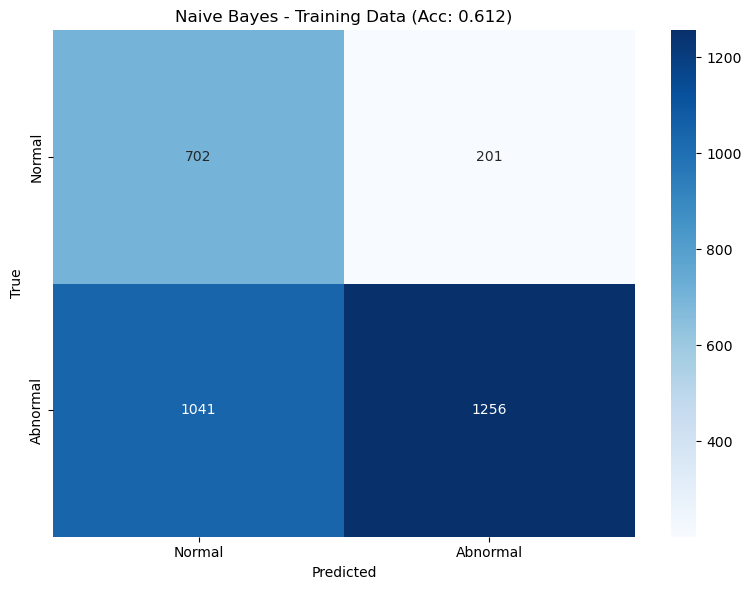

In [11]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Abnormal'],
            yticklabels=['Normal', 'Abnormal'])
plt.title(f'Naive Bayes - Training Data (Acc: {accuracy_nb_train:.3f})')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# PART 2: CNN

## Prepare Data

In [12]:
X_train_cnn = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, 1).astype('float32')
X_test_cnn = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, 1).astype('float32')

print(f"CNN data ready - Train: {X_train_cnn.shape}, Test: {X_test_cnn.shape}")

CNN data ready - Train: (3200, 128, 128, 1), Test: (1468, 128, 128, 1)


## Build CNN

In [13]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),
    
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),
    
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),
    
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),
    
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(2, activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("CNN built")

CNN built


## Train CNN

In [ ]:
# Split data for validation
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_cnn, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Data augmentation
datagen = ImageDataGenerator(rotation_range=15, width_shift_range=0.1, 
                             height_shift_range=0.1, zoom_range=0.15)

history = cnn_model.fit(
    datagen.flow(X_train_split, y_train_split, batch_size=32),
    epochs=50,
    validation_data=(X_val_split, y_val_split),
    steps_per_epoch=len(X_train_split) // 32,
    verbose=1
)

Epoch 1/50
60/80 ━━━━━━━━━━━━━━━━━━━━ 16s 825ms/step - accuracy: 0.6406 - loss: 2.4076

## Plot Training

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Val', linewidth=2)
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'], label='Train', linewidth=2)
ax2.plot(history.history['val_loss'], label='Val', linewidth=2)
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Check Performance on Training Data

In [ ]:
y_train_pred_cnn = np.argmax(cnn_model.predict(X_train_cnn, verbose=0), axis=1)

accuracy_cnn_train = accuracy_score(y_train, y_train_pred_cnn)
precision_cnn_train = precision_score(y_train, y_train_pred_cnn)
recall_cnn_train = recall_score(y_train, y_train_pred_cnn)
f1_cnn_train = f1_score(y_train, y_train_pred_cnn)

print("CNN - Training Performance")
print(f"Accuracy:  {accuracy_cnn_train:.4f}")
print(f"Precision: {precision_cnn_train:.4f}")
print(f"Recall:    {recall_cnn_train:.4f}")
print(f"F1-Score:  {f1_cnn_train:.4f}")

cm_cnn_train = confusion_matrix(y_train, y_train_pred_cnn)
print("\nConfusion Matrix:")
print(cm_cnn_train)

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cnn_train, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Abnormal'],
            yticklabels=['Normal', 'Abnormal'])
plt.title(f'CNN - Training Data (Acc: {accuracy_cnn_train:.3f})')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Predict on Test Data

In [ ]:
# Predict on test (no labels needed)
y_pred_cnn = np.argmax(cnn_model.predict(X_test_cnn, verbose=0), axis=1)

print(f"\nCNN predictions completed")
print(f"  Total predictions: {len(y_pred_cnn)}")
print(f"  Normal: {sum(y_pred_cnn==0)}, Abnormal: {sum(y_pred_cnn==1)}")

# COMPARISON - Training Performance

In [ ]:
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Naive Bayes': [accuracy_nb_train, precision_nb_train, recall_nb_train, f1_nb_train],
    'CNN': [accuracy_cnn_train, precision_cnn_train, recall_cnn_train, f1_cnn_train]
})

print("TRAINING PERFORMANCE COMPARISON")
print(comparison.to_string(index=False))
print(f"\nDifference (CNN - NB): {(accuracy_cnn_train - accuracy_nb_train)*100:+.2f}%")

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(comparison))
width = 0.35

ax.bar(x - width/2, comparison['Naive Bayes'], width, label='Naive Bayes', alpha=0.8)
ax.bar(x + width/2, comparison['CNN'], width, label='CNN', alpha=0.8)

ax.set_ylabel('Score')
ax.set_title('Training Performance Comparison', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(comparison['Metric'])
ax.legend()
ax.set_ylim([0, 1.1])
ax.grid(True, alpha=0.3, axis='y')

for i, (nb, cnn) in enumerate(zip(comparison['Naive Bayes'], comparison['CNN'])):
    ax.text(i - width/2, nb + 0.02, f'{nb:.3f}', ha='center', fontsize=10)
    ax.text(i + width/2, cnn + 0.02, f'{cnn:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## ROC Curve Comparison

In [ ]:
from sklearn.metrics import roc_curve, auc

# 1. Get probabilities for Naive Bayes
# Since it's a GaussianNB, we use predict_proba
y_train_prob_nb = nb.predict_proba(X_train_scaled)[:, 1]

# 2. Get probabilities for CNN
y_train_prob_cnn = cnn_model.predict(X_train_cnn).ravel()

# 3. Compute ROC curves
fpr_nb, tpr_nb, _ = roc_curve(y_train, y_train_prob_nb)
roc_auc_nb = auc(fpr_nb, tpr_nb)

fpr_cnn, tpr_cnn, _ = roc_curve(y_train, y_train_prob_cnn)
roc_auc_cnn = auc(fpr_cnn, tpr_cnn)

# 4. Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_nb, tpr_nb, color='blue', lw=2, label=f'Naive Bayes (AUC = {roc_auc_nb:.3f})')
plt.plot(fpr_cnn, tpr_cnn, color='green', lw=2, label=f'CNN (AUC = {roc_auc_cnn:.3f})')
plt.plot(,, color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# SAVE TEST PREDICTIONS

In [ ]:
# Create results dataframe
results = pd.DataFrame({
    'image_name': test_df['image_path'].values[:len(y_pred_nb)],
    'naive_bayes_prediction': ['Normal' if p==0 else 'Abnormal' for p in y_pred_nb],
    'cnn_prediction': ['Normal' if p==0 else 'Abnormal' for p in y_pred_cnn]
})

# Save to CSV
output_path = r'C:\Users\Gauri\Downloads\IDSA Project\pcod_predictions.csv'
results.to_csv(output_path, index=False)

print(f"✓ Predictions saved to {output_path}")
print(f"\nFirst 20 predictions:")
print(results.head(20))
print(f"\n... Total {len(results)} predictions")

In [ ]:
# Summary
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"\nTraining Data:")
print(f"  Total: {len(X_train)} images")
print(f"  Normal: {sum(y_train==0)}, Abnormal: {sum(y_train==1)}")

print(f"\nTest Data:")
print(f"  Total: {len(X_test)} images")

print(f"\nNaive Bayes Training Accuracy: {accuracy_nb_train:.4f}")
print(f"CNN Training Accuracy: {accuracy_cnn_train:.4f}")

print(f"\nTest Predictions:")
print(f"  Naive Bayes - Normal: {sum(y_pred_nb==0)}, Abnormal: {sum(y_pred_nb==1)}")
print(f"  CNN - Normal: {sum(y_pred_cnn==0)}, Abnormal: {sum(y_pred_cnn==1)}")

print(f"\n✓ Results saved to: {output_path}")